In [5]:
from environment import Environment
from collections import defaultdict
import pandas as pd
import os
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

N = 10000
N_UPDATES = 20          # number of update steps per sample
BATCH_SIZE = 1000
csv_path = "samples.csv"
updates_csv_path = "impact_updates.csv"

environment = Environment()
header_written = os.path.exists(csv_path)
updates_header_written = os.path.exists(updates_csv_path)

batch = defaultdict(list)
updates_batch = defaultdict(list)

for i in range(N):
    # --------------- Sampling
    environment.sample_features()
    environment.update_derived()

    # --------------- Saving samples
    for key, value in environment.samples.features.items():
        if key not in ("season", "geometry"):
            batch[key].append(value)

    for key, value in environment.derived.items():
        batch[key].append(value)

    batch["impact"].append(environment.impact)

    # --------------- Update steps — track how impact evolves
    updates_batch["sample_id"].append(i)
    updates_batch["update_0"].append(environment.impact)  # baseline before any updates

    for step in range(1, N_UPDATES + 1):
        environment.update_features()
        updates_batch[f"update_{step}"].append(environment.impact)

    # --------------- Flush to disk every BATCH_SIZE iterations
    if (i + 1) % BATCH_SIZE == 0:
        print(f"Batch {(i + 1) // BATCH_SIZE}")

        df = pd.DataFrame(batch)
        df.to_csv(csv_path, mode="a", index=False, header=not header_written)
        header_written = True
        batch = defaultdict(list)

        updates_df = pd.DataFrame(updates_batch)
        updates_df.to_csv(updates_csv_path, mode="a", index=False, header=not updates_header_written)
        updates_header_written = True
        updates_batch = defaultdict(list)

# Write any remaining rows
if batch:
    df = pd.DataFrame(batch)
    df.to_csv(csv_path, mode="a", index=False, header=not header_written)

if updates_batch:
    updates_df = pd.DataFrame(updates_batch)
    updates_df.to_csv(updates_csv_path, mode="a", index=False, header=not updates_header_written)

Batch 1
Batch 2
Batch 3
Batch 4
Batch 5
Batch 6
Batch 7
Batch 8
Batch 9
Batch 10


In [ ]:
'''summary = df.describe()
summary.to_csv("samples_describe.csv")'''

In [ ]:
'''desc = df.describe().T  # T = transpose

# Reset index so feature names become a regular column
desc.index.name = 'Feature'
desc.reset_index(inplace=True)

# Export to Excel
desc.to_excel('samples_describe.xlsx', index=False)'''

"desc = df.describe().T  # T = transpose\n\n# Reset index so feature names become a regular column\ndesc.index.name = 'Feature'\ndesc.reset_index(inplace=True)\n\n# Export to Excel\ndesc.to_excel('samples_describe.xlsx', index=False)"

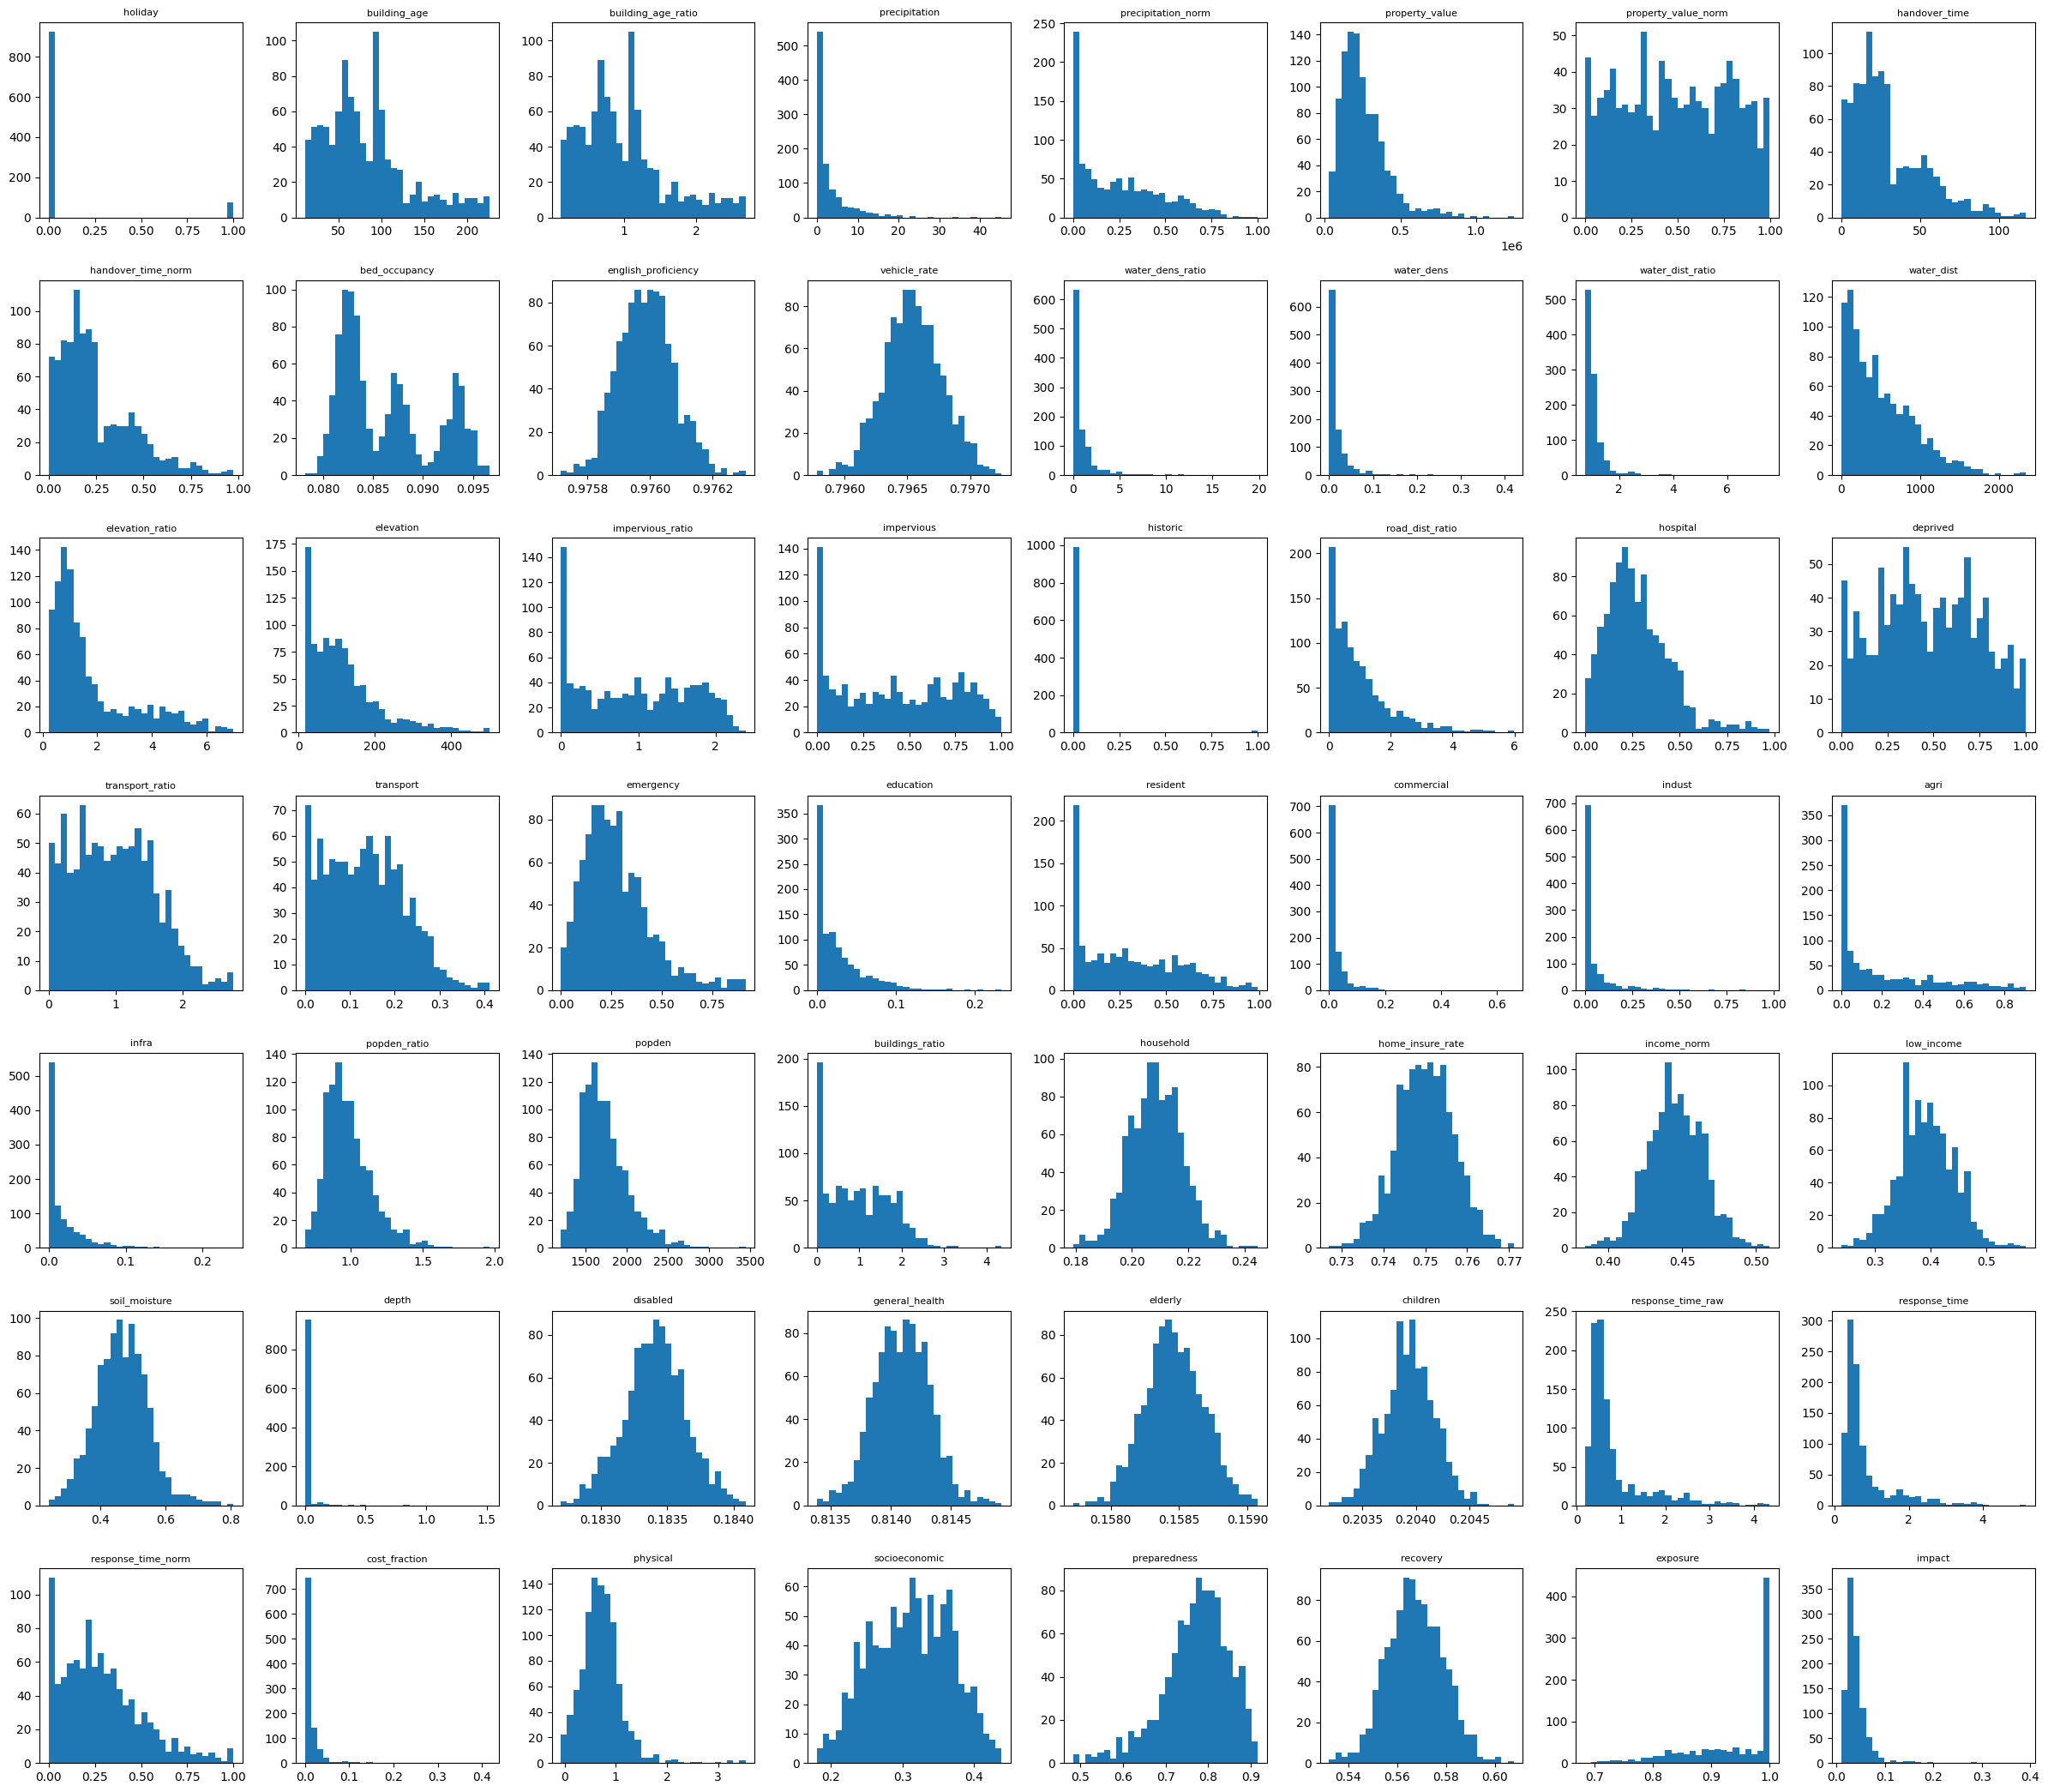

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import math

df = pd.read_csv("samples.csv")

# calculate grid size based on number of columns
n = len(df.columns)
ncols = math.ceil(math.sqrt(n))
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
axes = axes.flatten()

for ax, col in zip(axes, df.columns):
    ax.hist(df[col].dropna(), bins=30)
    ax.set_title(col, fontsize=8)

# hide unused axes
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
#plt.savefig('histograms-200k.png', dpi=150, facecolor='white', bbox_inches='tight')
plt.show()


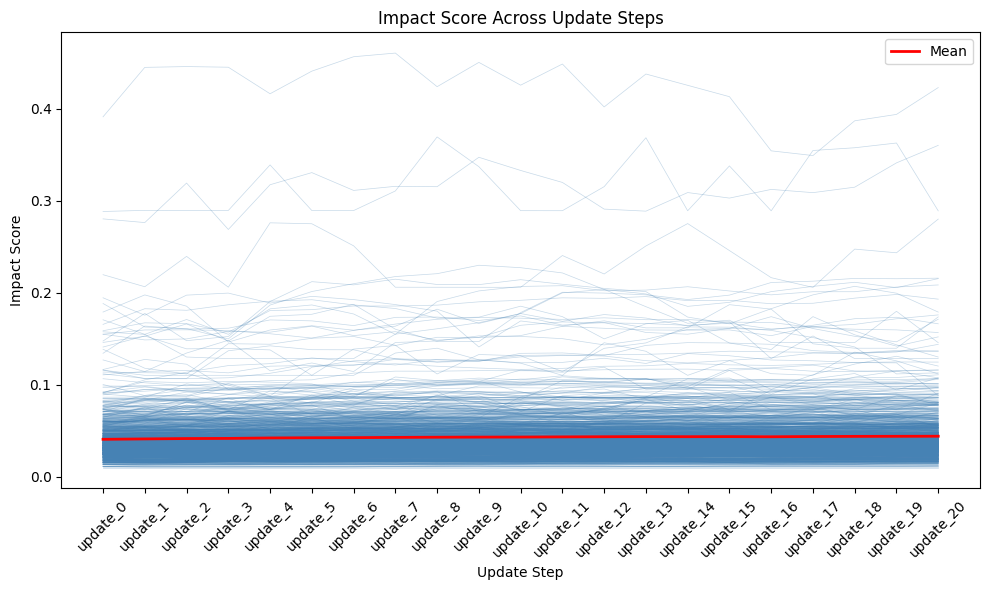

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("impact_updates.csv")
update_cols = [c for c in df.columns if c.startswith("update_")]
steps = range(len(update_cols))

fig, ax = plt.subplots(figsize=(10, 6))

# Individual scenario lines
for _, row in df.iterrows():
    ax.plot(steps, row[update_cols].values, alpha=0.3, color='steelblue', linewidth=0.5)

# Mean line
ax.plot(steps, df[update_cols].mean(), color='red', linewidth=2, label='Mean')

ax.set_xticks(steps)
ax.set_xticklabels(update_cols, rotation=45)
ax.set_xlabel("Update Step")
ax.set_ylabel("Impact Score")
ax.set_title("Impact Score Across Update Steps")
ax.legend()
plt.tight_layout()
plt.show()